# Lab 2: Global Optimization with Gaussian Processes

## Gaussian Process Summer School 2026


The goal of this lab session is to illustrate the concepts seen during the lecture in Gaussian processes for Global optimization. We will focus on two aspects of Bayesian Optimization (BO): (1) the choice of the model (2) the choice of the acquisition function.

This notebook uses the [BoTorch](https://botorch.org/) package which in turn is based on [PyTorch](https://pytorch.org/).

**Note**. In what follows, we use the Logarithmic EI (LogEI) acquisition function rather than the EI acquisition function. LogEI computes the natural logarithm of that expected improvement to improve numerical stability during gradient-based optimization. See this [reference](https://arxiv.org/html/2310.20708v2) for details.

## 1. Getting started

Now, just as in the previous lab, specify to include plots in the notebook and to import relevant libraries.

In [1]:
# Install BoTorch and other prerequisite packages
!pip install botorch
!pip install gpytorch
!pip install torch
!pip install matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 6.3 MB/s eta 0:00:00


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from numpy.random import seed
seed(12345)

import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils import standardize
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import LogExpectedImprovement, ExpectedImprovement, ProbabilityOfImprovement, UpperConfidenceBound
from botorch.optim import optimize_acqf

We will first define some utility functions for plotting. The next cell can be skimmed over as it contains no information relevent to learning about BO.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def plot_acquisition(model, Xdata, Ydata, acquisition_function, suggested_sample, bounds,
                     label_x: str=None, label_y: str=None):
    """
    Plots the model and the acquisition function.
        if self.input_dim = 1: Plots data, mean and variance in one plot and the acquisition function in another plot
        if self.input_dim = 2: as before but it separates the mean and variance of the model in two different plots
    :param label_x: Graph's x-axis label, if None it is renamed to 'x' (1D) or 'X1' (2D)
    :param label_y: Graph's y-axis label, if None it is renamed to 'f(x)' (1D) or 'X2' (2D)
    """
    return _plot_acquisition(bounds,
                            Xdata.shape[1],
                            model,
                            Xdata,
                            Ydata,
                            acquisition_function,
                            suggested_sample,
                            label_x,
                            label_y)

def _plot_acquisition(bounds, input_dim, model, Xdata, Ydata, acquisition_function, suggested_sample,
                     label_x=None, label_y=None, color_by_step=True):
    '''
    Plots of the model and the acquisition function in 1D and 2D examples.
    '''

    if input_dim ==1:
        # Plots for 1D input
        if not label_x:
            label_x = 'x'

        if not label_y:
            label_y = 'f(x)'

        x_grid = np.arange(bounds[0][0], bounds[0][1], 0.001)
        x_grid = x_grid.reshape(len(x_grid),1)
        x_grid_tensor = torch.from_numpy(x_grid).double()

        with torch.no_grad():
            posterior = model.posterior(x_grid_tensor)
            m = posterior.mean.numpy()
            v = posterior.variance.numpy()
            acq = acquisition_function(x_grid_tensor.unsqueeze(-2)).detach().numpy()

        acq_normalized = (acq - min(acq))/(max(acq) - min(acq))

        upper_conf_bound = m[:, 0] + 1.96 * np.sqrt(v)[:, 0]
        lower_conf_bound = m[:, 0] - 1.96 * np.sqrt(v)[:, 0]

        plt.fill_between(x_grid[:, 0], upper_conf_bound, lower_conf_bound, color='b', alpha=0.2)
        plt.plot(x_grid, lower_conf_bound, 'k-', alpha=0.2)
        plt.plot(x_grid, upper_conf_bound, 'k-', alpha=0.2)
        plt.plot(x_grid, m, 'k-', lw=1, alpha=0.6)

        plt.plot(Xdata, Ydata, 'r.', markersize=10)
        plt.axvline(x=suggested_sample[len(suggested_sample)-1], color='r')
        factor = max(upper_conf_bound) - min(lower_conf_bound)

        plt.plot(x_grid, 0.2*factor*acq_normalized - abs(min(lower_conf_bound)) - 0.25*factor, 'r-',
                 lw=2, label='Acquisition')
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.ylim(min(lower_conf_bound) - 0.25*factor,  max(upper_conf_bound) + 0.05*factor)
        plt.axvline(x=suggested_sample[len(suggested_sample)-1],color='r')
        plt.legend(loc='upper left')

    elif input_dim == 2:

        if not label_x:
            label_x = 'X1'

        if not label_y:
            label_y = 'X2'

        n = Xdata.shape[0]
        colors = np.linspace(0, 1, n)
        cmap = plt.cm.Reds
        norm = plt.Normalize(vmin=0, vmax=1)
        points_var_color = lambda X: plt.scatter(
            X[:,0], X[:,1], c=colors, label=u'Observations', cmap=cmap, norm=norm)
        points_one_color = lambda X: plt.plot(
            X[:,0], X[:,1], 'r.', markersize=10, label=u'Observations')
        X1 = np.linspace(bounds[0][0], bounds[0][1], 200)
        X2 = np.linspace(bounds[1][0], bounds[1][1], 200)
        x1, x2 = np.meshgrid(X1, X2)
        X = np.hstack((x1.reshape(200*200,1),x2.reshape(200*200,1)))
        X_tensor = torch.from_numpy(X).double()

        with torch.no_grad():
            posterior = model.posterior(X_tensor)
            m = posterior.mean.numpy()
            v = posterior.variance.numpy()
            acq = acquisition_function(X_tensor.unsqueeze(-2)).detach().numpy()

        acq_normalized = (acq - min(acq))/(max(acq) - min(acq))
        acq_normalized = acq_normalized.reshape((200,200))

        plt.figure(figsize=(15,5))
        plt.subplot(1, 3, 1)
        plt.contourf(X1, X2, m.reshape(200,200),100)
        plt.colorbar()
        if color_by_step:
            points_var_color(Xdata)
        else:
            points_one_color(Xdata)
        plt.ylabel(label_y)
        plt.title('Posterior mean')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))
        ##
        plt.subplot(1, 3, 2)
        plt.contourf(X1, X2, np.sqrt(v.reshape(200,200)),100)
        plt.colorbar()
        if color_by_step:
            points_var_color(Xdata)
        else:
            points_one_color(Xdata)
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.title('Posterior sd.')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))
        ##
        plt.subplot(1, 3, 3)
        plt.contourf(X1, X2, acq_normalized,100)
        plt.colorbar()
        plt.plot(suggested_sample[:,0],suggested_sample[:,1],'m.', markersize=10)
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.title('Acquisition function')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))

    else:
        raise ValueError(f'Cannot plot inputs higher than 2D, {input_dim} given')

def plot_convergence(X, Y):
    '''
    Plots the convergence of standard Bayesian optimization algorithms.

    :param X: Locations of evaluated points
    :param Y: Results of evaluations

    '''
    n = X.shape[0]

    ## Distances between consecutive x's
    aux = (X[1:n,:] - X[0:n-1,:])**2
    distances = np.sqrt(aux.sum(axis=1))

    plt.figure(figsize=(10,5))
    plt.subplot(1, 2, 1)
    plt.plot(list(range(n-1)), distances, '-ro')
    plt.xlabel('Iteration')
    plt.ylabel('d(x[n], x[n-1])')
    plt.title('Distance between consecutive x\'s')

    # Best found value at each iteration
    best_Y = np.minimum.accumulate(Y)

    plt.subplot(1, 2, 2)
    plt.plot(list(range(n)), best_Y, '-o')
    plt.title('Value of the best selected sample')
    plt.xlabel('Iteration')
    plt.ylabel('Best y')

### Remembering the basics

Before starting with the lab, remember that (BO) is an heuristic for global optimization of black-box functions. Let $f: {\mathcal X} \to R$ be a 'well behaved' continuous function defined on a compact subset ${\mathcal X} \subseteq R^d$. Our goal is to solve the global optimization problem of finding
$$ x_{M} = \arg \min_{x \in {\mathcal X}} f(x). $$

We assume that $f$ is a *black-box* from which only perturbed evaluations of the type $y_i = f(x_i) + \epsilon_i$, with $\epsilon_i \sim\mathcal{N}(0,\sigma^2)$, are  available. The goal is to find $x_M$ by minimizing the number of evaluations of $f$. To do this, we need to determine two crucial bits:

1. A **Gaussian process** that will capture the our beliefs on $f$.

2. An **acquisition function** that based on the model will be useful to determine where to collect new evaluations of f.

Remember that every time a new data point is collected the model is updated and the acquisition function optimized again.

### Running example

We start with a one-dimensional example. Consider here the Forrester function

$$ f(x) =(6x-2)^2 \sin(12x-4) $$

defined on the interval $[0, 1]$.

The minimum of this function is located at $x_{min}=0.78$. We assume that the evaluations of $f$ to are perturbed by zero-mean Gaussian noise with standard deviation 0.25. The Forrester function is part of the benchmark of functions of Emukit. To create the true function, the perturbed version and the boundaries of the problem you need to run the following cell.

In [4]:
def forrester_function(noise_standard_deviation=0.0):
    def f(x):
        return ((6 * x - 2) ** 2 * np.sin(12 * x - 4)).reshape(-1, 1)
    def noisy_f(x):
        return f(x) + np.random.normal(0, noise_standard_deviation, x.shape[0]).reshape(-1, 1)
    bounds = [(0.0, 1.0)]
    return (f, bounds) if noise_standard_deviation == 0 else (noisy_f, bounds)

f_true, bounds = forrester_function()
f_objective, _ = forrester_function(noise_standard_deviation=0.25)

Let's plot the true $f$:

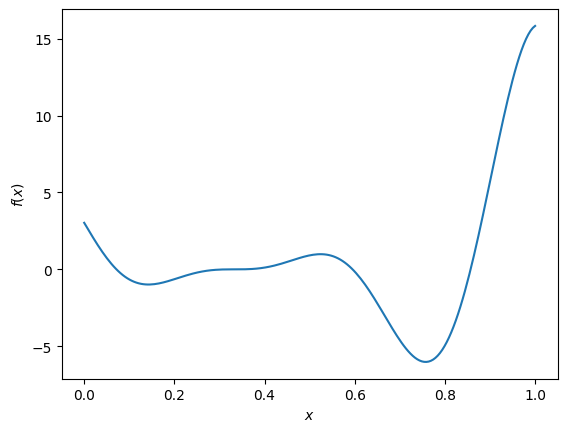

In [5]:
x_plot = np.linspace(bounds[0][0], bounds[0][1], 200)[:, None]
y_plot = f_true(x_plot)

plt.plot(x_plot, y_plot)
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.show()

`f_objective` is the function that we are going to optimize. You can define your own objective but it should be able to map any numpy array of dimension $n\times d$ (inputs) to a numpy array of dimension $n\times 1$ (outputs). For instance:

In [6]:
n = 8
x = np.random.rand(n).reshape(n,1)
x

array([[0.5955447 ],
       [0.96451452],
       [0.6531771 ],
       [0.74890664],
       [0.65356987],
       [0.74771481],
       [0.96130674],
       [0.0083883 ]])

In [7]:
f_objective(x)

array([[-0.09215098],
       [13.62800696],
       [-2.09304076],
       [-5.84832777],
       [-2.16797504],
       [-5.63775038],
       [13.41671102],
       [ 3.0607995 ]])

In BoTorch the bounds of the problem are defined as a tensor. For real valued parameters the upper and lower limits of the box in which the optimization will be performed shall be provided. In our example:

In [8]:
bounds_tensor = torch.tensor(bounds, dtype=torch.double).T

To use BO to solve this problem, we need to specify the following elements:
* The function to optimize.
* The box constrains of the problem.
* The model, that is fixed by default to be a GP with a RBF kernel in BoTorch.
* The acquisition function (and its parameters).

We create a GP model using BoTorch's SingleTaskGP

In [9]:
X_init = np.random.rand(3).reshape(3,1)
Y_init = f_objective(X_init)

X_init = torch.from_numpy(X_init).double()
Y_init = torch.from_numpy(Y_init).double()

model = SingleTaskGP(X_init, Y_init)
model.covar_module.lengthscale = 0.2
model.covar_module.outputscale = Y_init.var()
model.likelihood.noise = 0.1

mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll, options={"maxiter": 200, "disp": False})

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): RBFKernel(
      (lengthscale_prior): LogNormalPrior()
      (raw_lengthscale_constraint): GreaterThan(2.500E-02)
    )
    (outcome_transform): Standardize()
  )
)

And now we have all the elements to start optimizing $f$. We create the optimization problem instance. Note that you don't need to specify the evaluation budget of. This is because at this stage we are not running the optimization, we are just initializing the different elements of the BO algorithm.

In [10]:
X = X_init.clone()
Y = Y_init.clone()

In [11]:
print("Current X:", X)
print("Current Y:", Y)

Current X: tensor([[0.3256],
        [0.4396],
        [0.7297]], dtype=torch.float64)
Current Y: tensor([[-0.1351],
        [ 0.5085],
        [-4.8378]], dtype=torch.float64)


You will find that the optimisation loop state is already initialized, although with just the random initial locations.

Now we can run the optimisation loop itself for several iterations.

In [14]:
max_iter = 10
for i in range(max_iter):
    acq_EI = LogExpectedImprovement(model, best_f=Y.min(), maximize=False)

    candidates, _ = optimize_acqf(
        acq_EI,
        bounds_tensor,
        q=1,
        num_restarts=20,
        raw_samples=512,
        options={"batch_limit": 5, "maxiter": 200}
    )
    new_x = candidates.detach()
    new_y = torch.from_numpy(f_objective(new_x.numpy())).double()
    X = torch.cat([X, new_x])
    Y = torch.cat([Y, new_y])

    model = SingleTaskGP(X, Y)
    model.covar_module.lengthscale = 0.2
    model.covar_module.outputscale = Y.var()
    model.likelihood.noise = 0.1

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll, options={"maxiter": 200, "disp": False})

/usr/local/lib/python3.13/dist-packages/botorch/optim/optimize.py:844: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/usr/local/lib/python3.13/dist-packages/botorch/optim/optimize.py:844: RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


And that's it! We can re-inspect the loop state to see if it contains new data, and visualize the model and the acquisition function.

In [15]:
X

tensor([[0.3256],
        [0.4396],
        [0.7297],
        [0.8629],
        [0.6861],
        [0.0000],
        [0.7319],
        [0.1838],
        [1.0000],
        [0.7554],
        [0.7560],
        [0.7621],
        [0.7648],
        [0.5660],
        [0.7671],
        [0.7679],
        [0.7677],
        [0.7687],
        [0.7690],
        [0.7704],
        [0.0945],
        [0.7762],
        [0.7766]], dtype=torch.float64)

In [16]:
Y

tensor([[-0.1351],
        [ 0.5085],
        [-4.8378],
        [ 0.4693],
        [-4.1177],
        [ 3.0582],
        [-5.6287],
        [-0.6542],
        [15.8300],
        [-5.6829],
        [-6.1983],
        [-6.2157],
        [-6.5824],
        [ 0.2030],
        [-6.1822],
        [-5.8186],
        [-6.2769],
        [-5.9189],
        [-6.2109],
        [-5.8426],
        [-1.1483],
        [-5.8690],
        [-6.1969]], dtype=torch.float64)

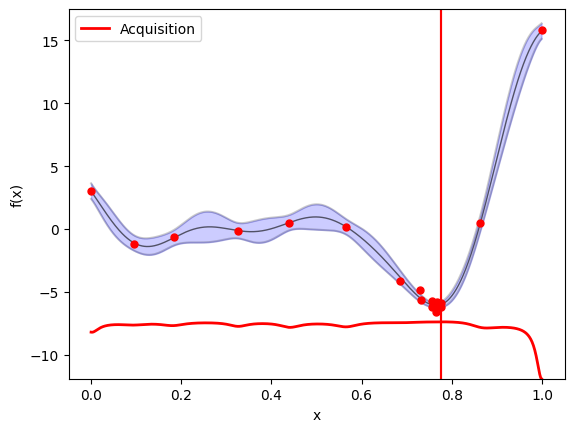

In [17]:
acq_EI = LogExpectedImprovement(model, best_f=Y.min(), maximize=False)
plot_acquisition(model, X.numpy(), Y.numpy(), acq_EI, X.numpy()[-1:], bounds)


# Note: For better visualization, may using ExpectedImprovement instead of LogExpectedImprovement.
# LogExpectedImprovement can cause visualization issues when plotted directly

You can only make the previous plot if the dimension of the problem is 1 or 2. However, you can always make a plot to see how the optimization evolved.

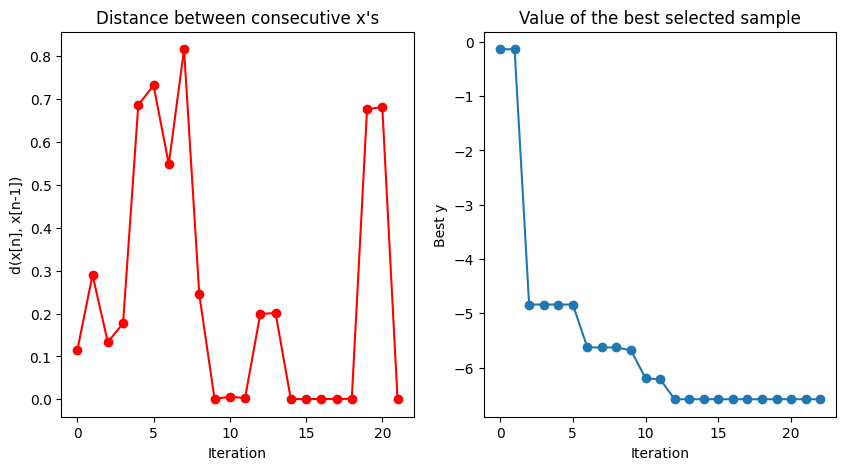

In [18]:
plot_convergence(X.numpy(), Y.numpy())

The first plot shows the distance between the last two collected observations at each iteration. This plot is useful to evaluate the convergence of the method. The second plot shows the best found value at each iteration. It is useful to compare different methods. The fastest the curve decreases the better the method.

### Exercise 1

Use Bayesian optimization to find the minimum of the function $f(x)= x^2 + 10 \sin(x)$ in the interval [-10, 10].

(a) Define the bounds of the problem, the function and check that it admits a numpy array of observations as input.

In [47]:
def function_sin(x, noise_standard_deviation = 1e-4):
  bounds = [(-10, 10)]
  # Generate noise with the same shape as x directly to prevent broadcasting issues
  noise = np.random.normal(0, noise_standard_deviation, x.shape)
  f = (x**2 + 10*np.sin(x) + noise).reshape(-1, 1)
  return(f, bounds)

n = 8
x = np.random.rand(n).reshape(n,1)
f_x, bounds = function_sin(x)

f_x

array([[2.86295062],
       [3.39966114],
       [0.84114117],
       [7.47429467],
       [5.13477845],
       [6.5765506 ],
       [6.29113941],
       [3.76226099]])

(b) Create an Emukit object for global optimization using a Matern5/2 kernel.

In [50]:
from gpytorch.kernels import MaternKernel

bounds_tensor = torch.tensor(bounds, dtype=torch.double).T

X_init = np.random.rand(3).reshape(3,1)
Y_init = function_sin(X_init)[0]

X_init = torch.from_numpy(X_init).double()
Y_init = torch.from_numpy(Y_init).double()

model = SingleTaskGP(X_init, Y_init, covar_module=MaternKernel(nu=2.5))
model.covar_module.lengthscale = 0.2
model.covar_module.outputscale = Y_init.var()
model.likelihood.noise = 1e-4 # Changed from 0.1 to 1e-4 as per Exercise 1(c)

mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll, options={"maxiter": 200, "disp": False})

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): MaternKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (outcome_transform): Standardize()
  )
)

(c) For stability reasons, constrain the noise of the model to be 10e-4.

In [51]:
model.likelihood.noise = 1e-4

(d) Run the optimization for 8 iterations. Make and comment the convergence plots. Has the method converged?

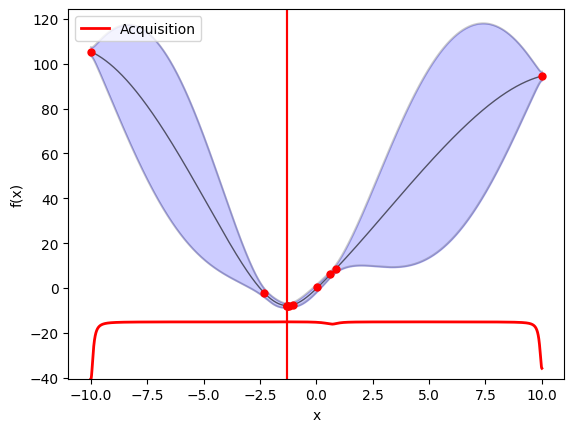

In [55]:
X = X_init.clone()
Y = Y_init.clone()
max_iter = 8
for i in range(max_iter):
    acq_EI = LogExpectedImprovement(model, best_f=Y.min(), maximize=False)

    candidates, _ = optimize_acqf(
        acq_EI,
        bounds_tensor,
        q=1,
        num_restarts=20,
        raw_samples=512,
        options={"batch_limit": 5, "maxiter": 200}
    )
    new_x = candidates.detach()
    # Corrected to use function_sin and extract the function value
    new_y = torch.from_numpy(function_sin(new_x.numpy())[0]).double()
    X = torch.cat([X, new_x])
    Y = torch.cat([Y, new_y])

    # Re-initialize the model with MaternKernel as per Exercise 1(b)
    # and set the noise as per Exercise 1(c)
    model = SingleTaskGP(X, Y, covar_module=MaternKernel(nu=2.5))
    model.covar_module.lengthscale = 0.2
    model.covar_module.outputscale = Y.var()
    model.likelihood.noise = 1e-4 # Changed from 0.1 to 1e-4

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll, options={"maxiter": 200, "disp": False})

acq_EI = LogExpectedImprovement(model, best_f=Y.min(), maximize=False)
plot_acquisition(model, X.numpy(), Y.numpy(), acq_EI, X.numpy()[-1:], bounds)

## 2. Acquisition functions

In this section we are going to have a look to different acquisition functions. BoTorch provides a variety of acquisition functions for Bayesian optimization, including the expected improvement ('EI') we already used, the probability of improvement ('PoI') and the upper confidence bound. In this section we will create these functions as separate objects and study their behavior.

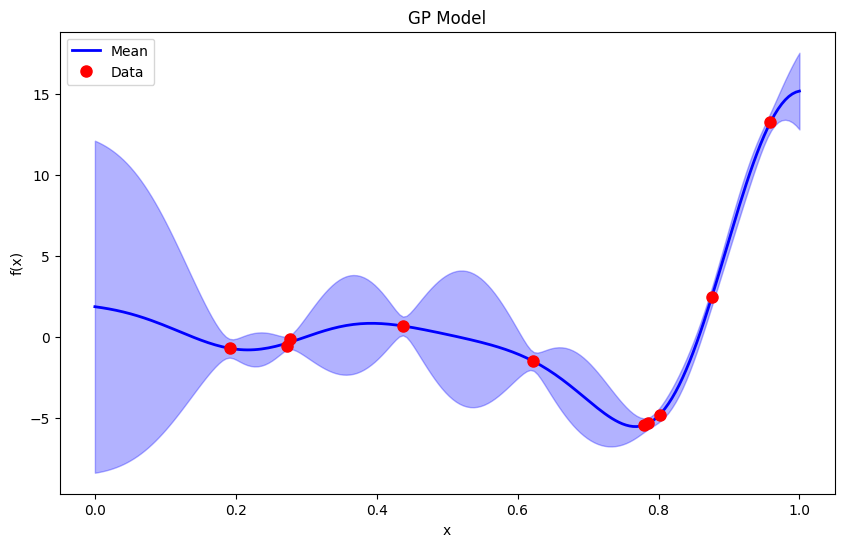

In [56]:
seed(1234)
n = 10
X = np.random.rand(n).reshape(n,1)
Y = f_objective(X)

X_tensor = torch.from_numpy(X).double()
Y_tensor = torch.from_numpy(Y).double()

model = SingleTaskGP(X_tensor, Y_tensor)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Plot the GP model
x_plot = np.linspace(0, 1, 200)[:, None]
x_plot_tensor = torch.from_numpy(x_plot).double()
with torch.no_grad():
    posterior = model.posterior(x_plot_tensor)
    m = posterior.mean.numpy()
    v = posterior.variance.numpy()

upper = m + 1.96 * np.sqrt(v)
lower = m - 1.96 * np.sqrt(v)

plt.figure(figsize=(10, 6))
plt.fill_between(x_plot.flatten(), upper.flatten(), lower.flatten(), alpha=0.3, color='blue')
plt.plot(x_plot, m, 'b-', linewidth=2, label='Mean')
plt.plot(X, Y, 'ro', markersize=8, label='Data')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('GP Model')
plt.show()

We define the bounds of the input space to be between zero and one.

In [57]:
bounds_tensor = torch.tensor([(0.0, 1.0)], dtype=torch.double).T

Now let's create the acquisition function objects.

In [66]:
acq_EI = LogExpectedImprovement(model, best_f=Y_tensor.min(), maximize=False)
acq_UCB = UpperConfidenceBound(model, beta=2.0, maximize=False)  # UCB for minimization = -LCB
acq_PI = ProbabilityOfImprovement(model, best_f=Y_tensor.min(), maximize=False)

The objects `acq_EI`, `acq_UCB`, `acq_PI` contain the acquisition functions and their gradients. By running the following piece of code you can visualize the three acquisitions. In this plot, the larger is the value of the acquisition, the better is the point.

**Note**: The acquisition functions have different scales, so we normalize them for visual comparison.

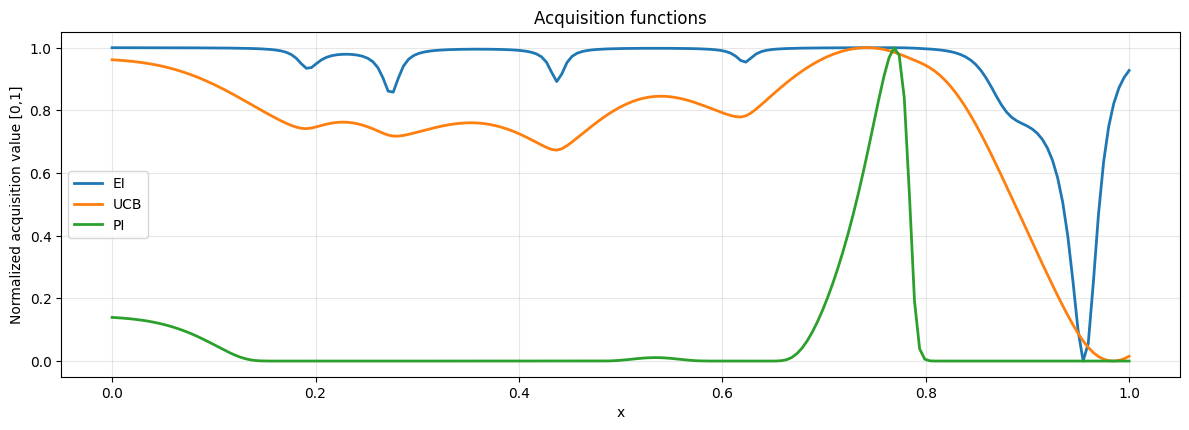

In [59]:
# Plot the three acquisition functions for comparison
X_grid = torch.linspace(0, 1, 200).reshape(-1, 1).double()
plt.figure(figsize=(12,8))

with torch.no_grad():
    ei_values = acq_EI(X_grid.unsqueeze(-2)).detach().numpy()
    ucb_values = acq_UCB(X_grid.unsqueeze(-2)).detach().numpy()
    pi_values = acq_PI(X_grid.unsqueeze(-2)).detach().numpy()

plt.subplot(2, 1, 2)
plt.title('Acquisition functions')

ei_norm = (ei_values - ei_values.min()) / (ei_values.max() - ei_values.min()) if ei_values.max() > ei_values.min() else ei_values
ucb_norm = (ucb_values - ucb_values.min()) / (ucb_values.max() - ucb_values.min()) if ucb_values.max() > ucb_values.min() else ucb_values
pi_norm = (pi_values - pi_values.min()) / (pi_values.max() - pi_values.min()) if pi_values.max() > pi_values.min() else pi_values

plt.plot(X_grid, ei_norm, label='EI', linewidth=2)
plt.plot(X_grid, ucb_norm, label='UCB', linewidth=2)
plt.plot(X_grid, pi_norm, label='PI', linewidth=2)
plt.xlabel('x')
plt.ylabel('Normalized acquisition value [0,1]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Exercise 2

(a) According to the previous plot, what areas in the domain are worth exploring and why? How can we interpret the previous plot in terms of the exploration/exploitation trade off of each one of the three acquisitions?

(b) Now make a plot comparing the shape of the UCB acquisition with values different values of the beta parameter. Use the values $[0,0.1,0.25,0.5,1,2,5]$. How does the decision about where to collect the sample change when we increase the value of the parameter?

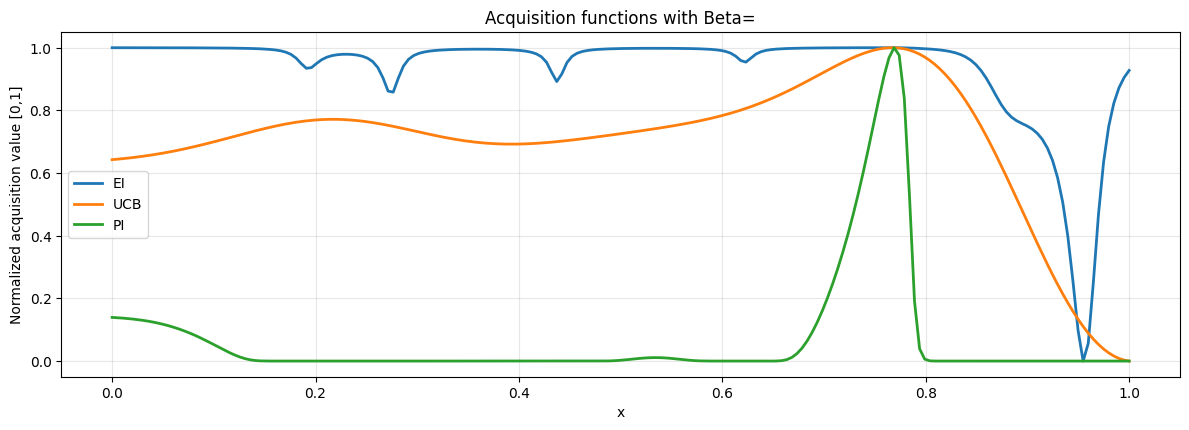

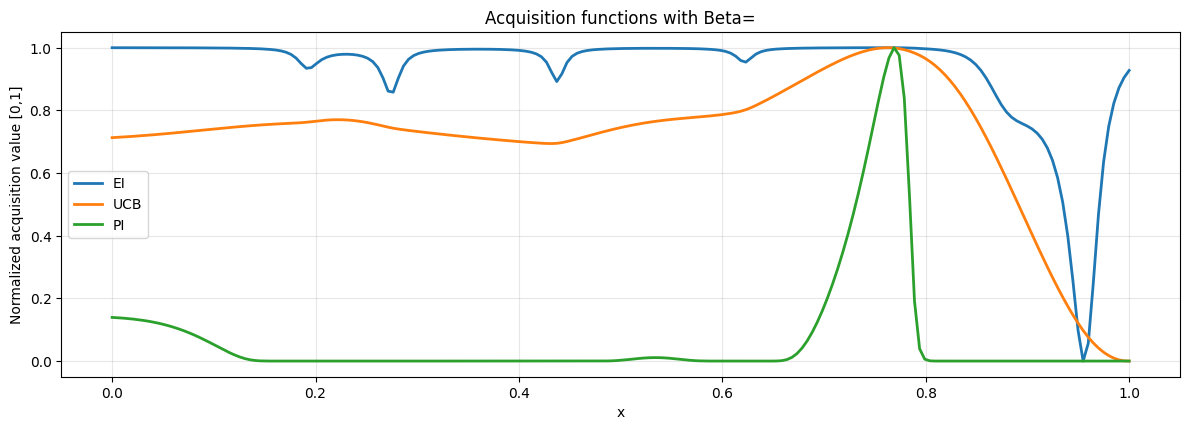

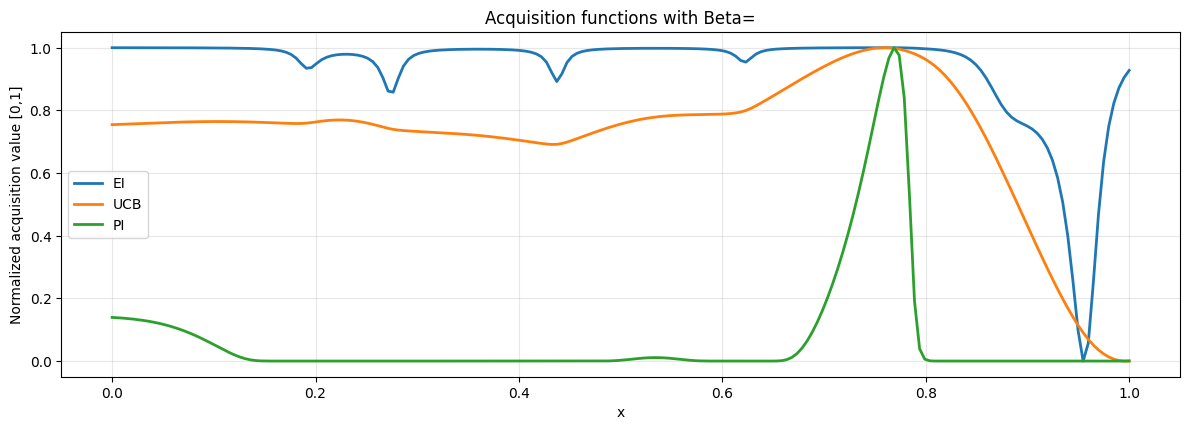

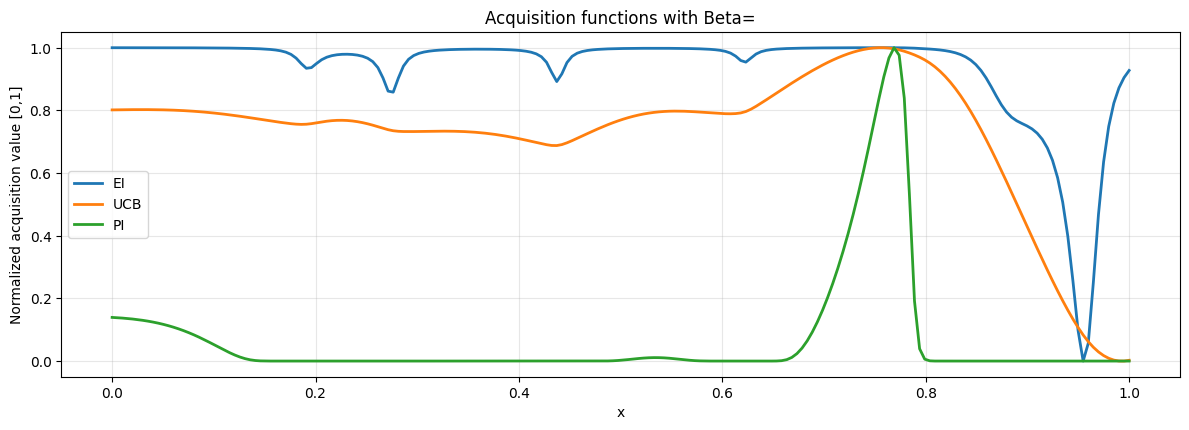

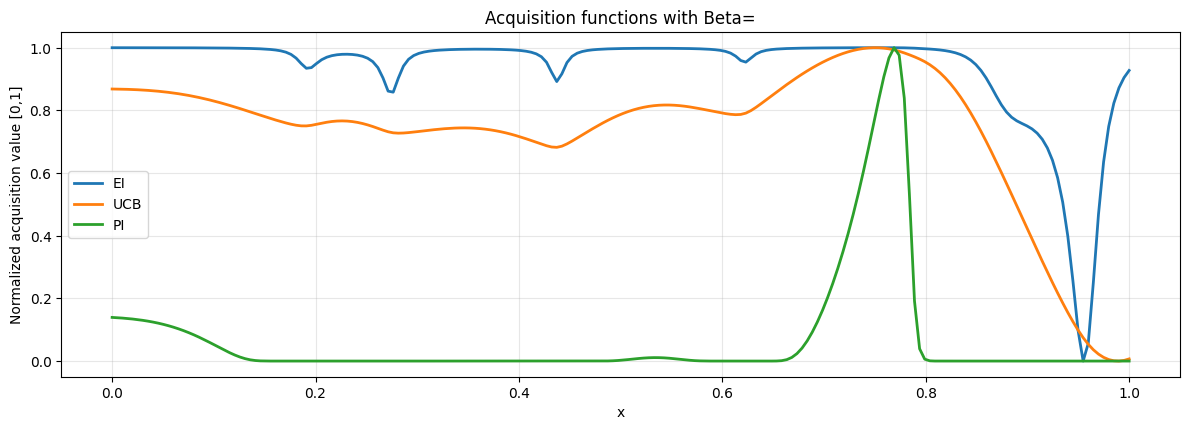

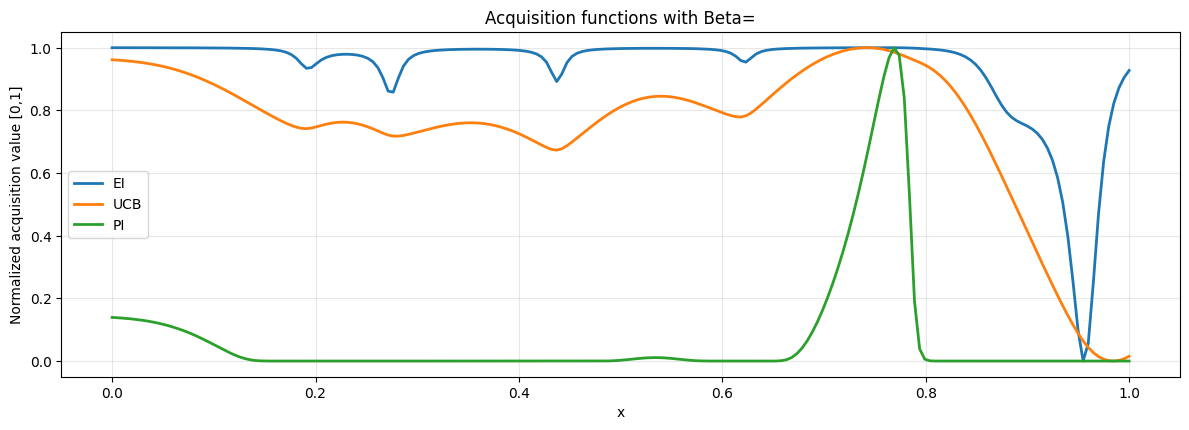

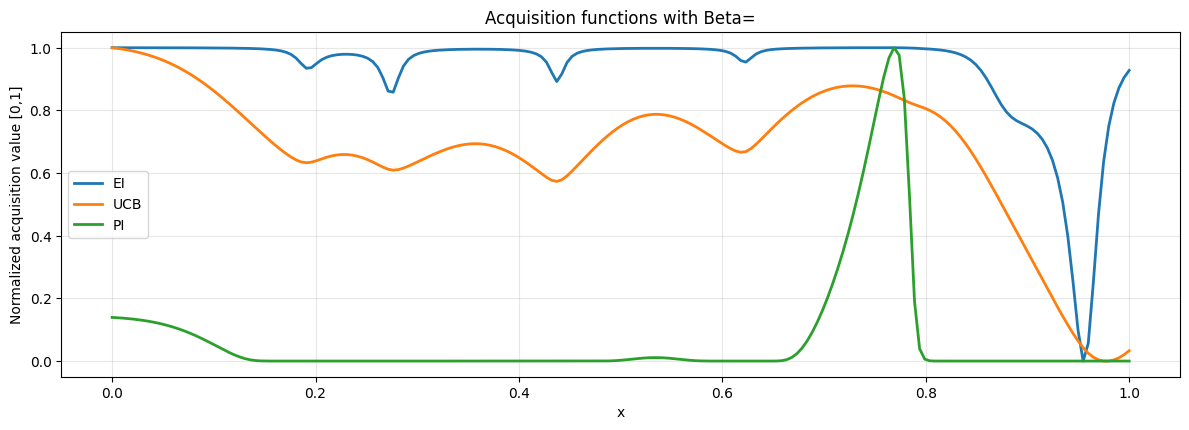

In [64]:
beta = [0, 0.1, 0.25, 0.5, 1, 2, 5]
for b in beta:
    acq_UCB = UpperConfidenceBound(model, beta=b, maximize=False)
    # Plot the three acquisition functions for comparison
    X_grid = torch.linspace(0, 1, 200).reshape(-1, 1).double()
    plt.figure(figsize=(12,8))

    with torch.no_grad():
        ei_values = acq_EI(X_grid.unsqueeze(-2)).detach().numpy()
        ucb_values = acq_UCB(X_grid.unsqueeze(-2)).detach().numpy()
        pi_values = acq_PI(X_grid.unsqueeze(-2)).detach().numpy()

    plt.subplot(2, 1, 2)
    plt.title('Acquisition functions with Beta=')

    ei_norm = (ei_values - ei_values.min()) / (ei_values.max() - ei_values.min()) if ei_values.max() > ei_values.min() else ei_values
    ucb_norm = (ucb_values - ucb_values.min()) / (ucb_values.max() - ucb_values.min()) if ucb_values.max() > ucb_values.min() else ucb_values
    pi_norm = (pi_values - pi_values.min()) / (pi_values.max() - pi_values.min()) if pi_values.max() > pi_values.min() else pi_values

    plt.plot(X_grid, ei_norm, label='EI', linewidth=2)
    plt.plot(X_grid, ucb_norm, label='UCB', linewidth=2)
    plt.plot(X_grid, pi_norm, label='PI', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('Normalized acquisition value [0,1]')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


### Exercise 3

Consider the sixhumpcamel function defined as
$$f(x_1,x_2) = \left(4-2.1x_1^2 + \frac{x_1^4}{3} \right)x_1^2 + x_1x_2 + (-4 +4x_2^2)x_2^2,$$

in $[-2,2]\times [-1,1]$. This function has two global minima, at $(0.0898,-0.7126)$ and $(-0.0898,0.7126)$. We implement this function manually:

In [61]:
def sixhumpcamel_function():
    def f(x):
        x1, x2 = x[:, 0], x[:, 1]
        term1 = (4 - 2.1 * x1**2 + x1**4 / 3) * x1**2
        term2 = x1 * x2
        term3 = (-4 + 4 * x2**2) * x2**2
        return (term1 + term2 + term3).reshape(-1, 1)
    bounds = [(-2.0, 2.0), (-1.0, 1.0)]
    return f, bounds

f_shc, space_shc = sixhumpcamel_function()
bounds_tensor_shc = torch.tensor(space_shc, dtype=torch.double).T

(a) Create three objects to optimize this function using EI (with parameter equal to zero), UCB (with parameter equal to 2) and PI (with parameter equal to zero). Use the same initial data in the three cases (hint: create a separate BoTorch model for each BO object and use the same X and Y).

In [70]:
n_init = 5
X_init_shc = torch.rand(n_init, 2, dtype=torch.double)
# Scale X_init_shc to fit the bounds [-2,2] x [-1,1]
X_init_shc[:, 0] = X_init_shc[:, 0] * (space_shc[0][1] - space_shc[0][0]) + space_shc[0][0]
X_init_shc[:, 1] = X_init_shc[:, 1] * (space_shc[1][1] - space_shc[1][0]) + space_shc[1][0]

Y_init_shc = f_shc(X_init_shc.numpy())
Y_init_shc = torch.from_numpy(Y_init_shc).double()
# Ensure Y_init_shc has 2 dimensions (N, 1) if it's currently 1D (N,)
if Y_init_shc.ndim == 1:
    Y_init_shc = Y_init_shc.unsqueeze(-1)

# Model for EI
model_EI = SingleTaskGP(X_init_shc, Y_init_shc)
mll_EI = ExactMarginalLogLikelihood(model_EI.likelihood, model_EI)
fit_gpytorch_mll(mll_EI)
acq_EI_shc = LogExpectedImprovement(model_EI, best_f=Y_init_shc.min(), maximize=False)

# Model for UCB
model_UCB = SingleTaskGP(X_init_shc, Y_init_shc)
mll_UCB = ExactMarginalLogLikelihood(model_UCB.likelihood, model_UCB)
fit_gpytorch_mll(mll_UCB)
acq_UCB_shc = UpperConfidenceBound(model_UCB, beta=2.0, maximize=False)

# Model for PI
model_PI = SingleTaskGP(X_init_shc, Y_init_shc)
mll_PI = ExactMarginalLogLikelihood(model_PI.likelihood, model_PI)
fit_gpytorch_mll(mll_PI)
acq_PI_shc = ProbabilityOfImprovement(model_PI, best_f=Y_init_shc.min(), maximize=False)

/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


(b) In the three cases run the optimization for 30 iterations

In [71]:
max_iter_shc = 30

# --- Optimization loop for EI ---
# Clone initial data for EI to ensure independence
X_EI = X_init_shc.clone()
Y_EI = Y_init_shc.clone()
# Re-initialize the model for EI with initial data and fit MLL
model_EI = SingleTaskGP(X_EI, Y_EI)
mll_EI = ExactMarginalLogLikelihood(model_EI.likelihood, model_EI)
fit_gpytorch_mll(mll_EI)
acq_EI_shc = LogExpectedImprovement(model_EI, best_f=Y_EI.min(), maximize=False)

for i in range(max_iter_shc):
    # Optimize acquisition function to get new candidate point
    candidates, _ = optimize_acqf(
        acq_EI_shc,
        bounds_tensor_shc,
        q=1,
        num_restarts=20,
        raw_samples=512,
        options={"batch_limit": 5, "maxiter": 200}
    )
    new_x_ei = candidates.detach()
    # Evaluate the objective function at the new candidate point
    new_y_ei = torch.from_numpy(f_shc(new_x_ei.numpy())).double()
    if new_y_ei.ndim == 1:
        new_y_ei = new_y_ei.unsqueeze(-1)

    # Add new observation to dataset
    X_EI = torch.cat([X_EI, new_x_ei])
    Y_EI = torch.cat([Y_EI, new_y_ei])

    # Update model and refit MLL
    model_EI = SingleTaskGP(X_EI, Y_EI)
    mll_EI = ExactMarginalLogLikelihood(model_EI.likelihood, model_EI)
    fit_gpytorch_mll(mll_EI)
    acq_EI_shc = LogExpectedImprovement(model_EI, best_f=Y_EI.min(), maximize=False)

# --- Optimization loop for UCB ---
# Clone initial data for UCB to ensure independence
X_UCB = X_init_shc.clone()
Y_UCB = Y_init_shc.clone()
# Re-initialize the model for UCB with initial data and fit MLL
model_UCB = SingleTaskGP(X_UCB, Y_UCB)
mll_UCB = ExactMarginalLogLikelihood(model_UCB.likelihood, model_UCB)
fit_gpytorch_mll(mll_UCB)
acq_UCB_shc = UpperConfidenceBound(model_UCB, beta=2.0, maximize=False)

for i in range(max_iter_shc):
    # Optimize acquisition function
    candidates, _ = optimize_acqf(
        acq_UCB_shc,
        bounds_tensor_shc,
        q=1,
        num_restarts=20,
        raw_samples=512,
        options={"batch_limit": 5, "maxiter": 200}
    )
    new_x_ucb = candidates.detach()
    new_y_ucb = torch.from_numpy(f_shc(new_x_ucb.numpy())).double()
    if new_y_ucb.ndim == 1:
        new_y_ucb = new_y_ucb.unsqueeze(-1)

    X_UCB = torch.cat([X_UCB, new_x_ucb])
    Y_UCB = torch.cat([Y_UCB, new_y_ucb])

    # Update model and refit MLL
    model_UCB = SingleTaskGP(X_UCB, Y_UCB)
mll_UCB = ExactMarginalLogLikelihood(model_UCB.likelihood, model_UCB)
fit_gpytorch_mll(mll_UCB)
acq_UCB_shc = UpperConfidenceBound(model_UCB, beta=2.0, maximize=False)

# --- Optimization loop for PI ---
# Clone initial data for PI to ensure independence
X_PI = X_init_shc.clone()
Y_PI = Y_init_shc.clone()
# Re-initialize the model for PI with initial data and fit MLL
model_PI = SingleTaskGP(X_PI, Y_PI)
mll_PI = ExactMarginalLogLikelihood(model_PI.likelihood, model_PI)
fit_gpytorch_mll(mll_PI)
acq_PI_shc = ProbabilityOfImprovement(model_PI, best_f=Y_PI.min(), maximize=False)

for i in range(max_iter_shc):
    # Optimize acquisition function
    candidates, _ = optimize_acqf(
        acq_PI_shc,
        bounds_tensor_shc,
        q=1,
        num_restarts=20,
        raw_samples=512,
        options={"batch_limit": 5, "maxiter": 200}
    )
    new_x_pi = candidates.detach()
    new_y_pi = torch.from_numpy(f_shc(new_x_pi.numpy())).double()
    if new_y_pi.ndim == 1:
        new_y_pi = new_y_pi.unsqueeze(-1)

    X_PI = torch.cat([X_PI, new_x_pi])
    Y_PI = torch.cat([Y_PI, new_y_pi])

    # Update model and refit MLL
    model_PI = SingleTaskGP(X_PI, Y_PI)
    mll_PI = ExactMarginalLogLikelihood(model_PI.likelihood, model_PI)
    fit_gpytorch_mll(mll_PI)
    acq_PI_shc = ProbabilityOfImprovement(model_PI, best_f=Y_PI.min(), maximize=False)

/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/usr/local/lib/python3.13/dist-packages/botorch/models/utils/assorted.py:276: InputDataWarning: 

(c) Now make a plot comparing the three methods. The x axis should contain the number of iterations and y axis the best found value. Which acquisition has the best performance in this example?

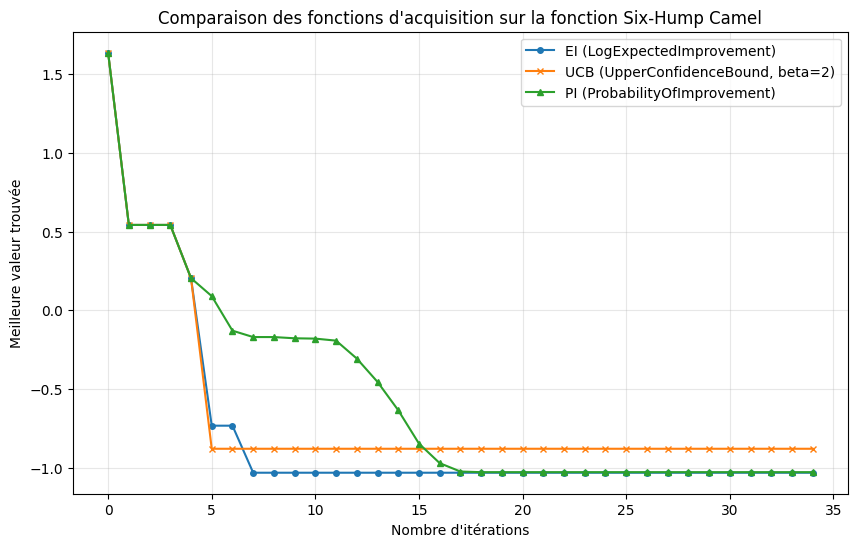

Meilleure valeur finale trouvée par EI: -1.0306992182861596
Meilleure valeur finale trouvée par UCB: -0.8785920821297494
Meilleure valeur finale trouvée par PI: -1.0272633490090466


In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the best found value at each iteration for each acquisition function
best_Y_EI = np.minimum.accumulate(Y_EI.cpu().numpy().flatten())
best_Y_UCB = np.minimum.accumulate(Y_UCB.cpu().numpy().flatten())
best_Y_PI = np.minimum.accumulate(Y_PI.cpu().numpy().flatten())

# Create a common x-axis for the number of iterations
# The number of data points is initial_points (n_init) + max_iterations (max_iter_shc)
iterations = np.arange(len(best_Y_EI))

plt.figure(figsize=(10, 6))
plt.plot(iterations, best_Y_EI, label='EI (LogExpectedImprovement)', marker='o', markersize=4)
plt.plot(iterations, best_Y_UCB, label='UCB (UpperConfidenceBound, beta=2)', marker='x', markersize=4)
plt.plot(iterations, best_Y_PI, label='PI (ProbabilityOfImprovement)', marker='^', markersize=4)

plt.xlabel('Nombre d\'itérations')
plt.ylabel('Meilleure valeur trouvée')
plt.title('Comparaison des fonctions d\'acquisition sur la fonction Six-Hump Camel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Meilleure valeur finale trouvée par EI:", best_Y_EI[-1])
print("Meilleure valeur finale trouvée par UCB:", best_Y_UCB[-1])
print("Meilleure valeur finale trouvée par PI:", best_Y_PI[-1])

(d) Compare the models and the acquisition functions in the three cases (after the 30 iterations). What do you observe?

In [74]:
C'est une excellente question qui touche au cœur des différences entre les fonctions d'acquisition en optimisation bayésienne. Voici une explication :

**Pourquoi la *Probability of Improvement* (PI) est-elle la plus lente à converger ?**

La fonction d'acquisition PI est souvent considérée comme plus "gloutonne" (exploitation-centrée) que l'Expected Improvement (EI). Elle maximise la probabilité de trouver un point qui est meilleur que le meilleur point actuel (`best_f`). Cependant, elle ne tient pas compte de **l'ampleur de l'amélioration** potentielle. Si un point a une très faible chance de s'améliorer légèrement mais une autre région a une chance modérée de s'améliorer considérablement, PI pourrait choisir la première option. Cela peut la rendre très sensible aux minima locaux et la conduire à explorer des régions prometteuses de manière inefficace, ralentissant ainsi sa convergence vers l'optimum global.

**Pourquoi la *LogExpectedImprovement* (LogEI) est-elle la plus rapide et la meilleure en sortie ?**

La LogEI (et EI) est généralement plus performante car elle trouve un meilleur équilibre entre l'exploration et l'exploitation. Au lieu de simplement considérer la *probabilité* d'amélioration, elle intègre **l'amélioration *attendue***, c'est-à-dire la probabilité multipliée par l'ampleur de l'amélioration. Cela signifie qu'elle est attirée non seulement par les régions où l'amélioration est probable, mais aussi par celles où l'amélioration pourrait être importante. Elle favorise ainsi à la fois l'exploration des zones incertaines (où l'amélioration potentielle est élevée) et l'exploitation des zones connues comme étant déjà bonnes. Cette capacité à explorer intelligemment tout en exploitant les meilleures régions connues lui permet souvent de converger plus rapidement et de trouver un meilleur optimum global, comme observé dans cet exemple.

SyntaxError: unterminated string literal (detected at line 5) (375233715.py, line 5)

La fonction d'acquisition PI est souvent considérée comme plus "gloutonne" (exploitation-centrée) que l'Expected Improvement (EI). Elle maximise la probabilité de trouver un point qui est meilleur que le meilleur point actuel (`best_f`). Cependant, elle ne tient pas compte de **l'ampleur de l'amélioration** potentielle. Si un point a une très faible chance de s'améliorer légèrement mais une autre région a une chance modérée de s'améliorer considérablement, PI pourrait choisir la première option. Cela peut la rendre très sensible aux minima locaux et la conduire à explorer des régions prometteuses de manière inefficace, ralentissant ainsi sa convergence vers l'optimum global.

La LogEI (et EI) est généralement plus performante car elle trouve un meilleur équilibre entre l'exploration et l'exploitation. Au lieu de simplement considérer la probabilité d'amélioration, elle intègre l'amélioration attendue, c'est-à-dire la probabilité multipliée par l'ampleur de l'amélioration. Cela signifie qu'elle est attirée non seulement par les régions où l'amélioration est probable, mais aussi par celles où l'amélioration pourrait être importante. Elle favorise ainsi à la fois l'exploration des zones incertaines (où l'amélioration potentielle est élevée) et l'exploitation des zones connues comme étant déjà bonnes. Cette capacité à explorer intelligemment tout en exploitant les meilleures régions connues lui permet souvent de converger plus rapidement et de trouver un meilleur optimum global, comme observé dans cet exemple.



---
### Credit

This notebook was written in Botorch by Qiyu Wei, adopted from the earlier GPyOpt version written by Javier Gonzalez and Andrei Paleyes.